# Calculadora de Juros Compostos

## Quanto tempo para chegar ao primeiro milhão?

### Plano de aportes:
- **Anos 1-2:** R$ 300,00/mês
- **Anos 3-4:** R$ 500,00/mês
- **Anos 5-6:** R$ 700,00/mês
- **Anos 7+:** R$ 1.000,00/mês

**Taxa:** 0,83% ao mês (~10,4% a.a.)

In [1]:
# Parâmetros
taxa_mensal = 0.0083  # 0,83%
alvo = 1_000_000

# Fases
fases = [
    (24, 300, "R$ 300/mês (2 anos)"),
    (24, 500, "R$ 500/mês (2 anos)"),
    (24, 700, "R$ 700/mês (2 anos)"),
    (None, 1000, "R$ 1.000/mês (até 1M)"),
]

saldo = 0
total_investido = 0
meses_total = 0
historico = []

for meses, aporte, nome in fases:
    if meses is None:
        n = 0
        while saldo < alvo:
            saldo = saldo * (1 + taxa_mensal) + aporte
            total_investido += aporte
            n += 1
        meses_total += n
        historico.append((meses_total, saldo, nome, aporte, n))
    else:
        for _ in range(meses):
            saldo = saldo * (1 + taxa_mensal) + aporte
            total_investido += aporte
        meses_total += meses
        historico.append((meses_total, saldo, nome, aporte, meses))

anos = meses_total // 12
meses_resto = meses_total % 12
juros = saldo - total_investido

print(f"{"="*60}")
print(f"  TEMPO TOTAL: {anos} anos e {meses_resto} meses ({meses_total} meses)")
print(f"  SALDO FINAL: R$ {saldo:,.2f}")
print(f"  TOTAL INVESTIDO: R$ {total_investido:,.2f}")
print(f"  TOTAL EM JUROS:  R$ {juros:,.2f}")
print(f"{"="*60}")

  TEMPO TOTAL: 25 anos e 3 meses (303 meses)
  SALDO FINAL: R$ 1,005,913.87
  TOTAL INVESTIDO: R$ 267,000.00
  TOTAL EM JUROS:  R$ 738,913.87


## Evolução por fase

In [8]:
print(f"{"-"*70}")
print(f"{'Fase':<30} {'Período':<15} {'Aporte':<15} {'Saldo':<15}")
print(f"{"-"*70}")

saldo = 0
meses = 0
for fase_nome, aporte_nome, meses_nome in [
    ("Anos 1-2", "R$ 300/mês", 24),
    ("Anos 3-4", "R$ 500/mês", 24),
    ("Anos 5-6", "R$ 700/mês", 24),
]:
    for _ in range(meses_nome):
        saldo = saldo * (1 + taxa_mensal) + {"R$ 300/mês": 300, "R$ 500/mês": 500, "R$ 700/mês": 700}[aporte_nome]
    meses += meses_nome
    print(f"{fase_nome:<30} {f'{meses} meses':<15} {aporte_nome:<15} R$ {saldo:>8,.2f}")

# Fase 4
n = 0
while saldo < alvo:
    saldo = saldo * (1 + taxa_mensal) + 1000
    n += 1
meses += n
print(f"{"-"*70}")
print(f"{'Anos 7+ (até 1M)':<30} {f'{n} meses':<15} {'R$ 1.000/mês':<15} R$ {saldo:>8,.2f}")
print(f"{"-"*70}")

anos = meses // 12
meses_resto = meses % 12
print(f"\nTOTAL: {anos} anos e {meses_resto} meses")

----------------------------------------------------------------------
Fase                           Período         Aporte          Saldo          
----------------------------------------------------------------------
Anos 1-2                       24 meses        R$ 300/mês      R$ 7,930.95
Anos 3-4                       48 meses        R$ 500/mês      R$ 22,889.45
Anos 5-6                       72 meses        R$ 700/mês      R$ 46,417.48
----------------------------------------------------------------------
Anos 7+ (até 1M)               231 meses       R$ 1.000/mês    R$ 1,005,913.87
----------------------------------------------------------------------

TOTAL: 25 anos e 3 meses


## Gráfico de evolução

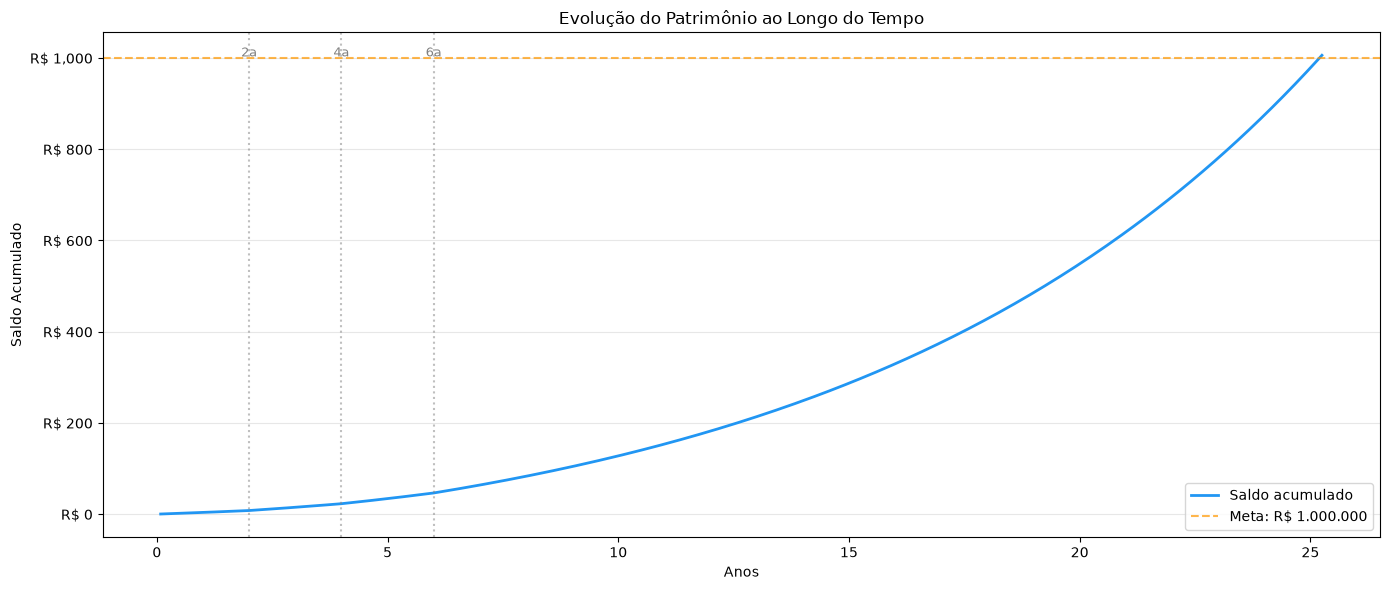

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Simulação mês a mês
saldo = 0
saldos = []
aportes = []

for mes in range(1, meses_total + 1):
    if mes <= 24:
        a = 300
    elif mes <= 48:
        a = 500
    elif mes <= 72:
        a = 700
    else:
        a = 1000
    saldo = saldo * (1 + taxa_mensal) + a
    saldos.append(saldo)
    aportes.append(a)

# Gráfico
fig, ax = plt.subplots(figsize=(14, 6))

anos_eixo = [m / 12 for m in range(1, meses_total + 1)]
ax.plot(anos_eixo, saldos, label='Saldo acumulado', linewidth=2, color='#2196F3')
ax.axhline(y=1_000_000, color='#FF9800', linestyle='--', alpha=0.7, label='Meta: R$ 1.000.000')

# Linhas divisórias das fases
for a in [2, 4, 6]:
    ax.axvline(x=a, color='gray', linestyle=':', alpha=0.5)
    ax.text(a, ax.get_ylim()[1]*0.95, f'{a}a', ha='center', fontsize=9, color='gray')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1000:,.0f}'))
ax.set_xlabel('Anos')
ax.set_ylabel('Saldo Acumulado')
ax.set_title('Evolução do Patrimônio ao Longo do Tempo')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Composição do valor final

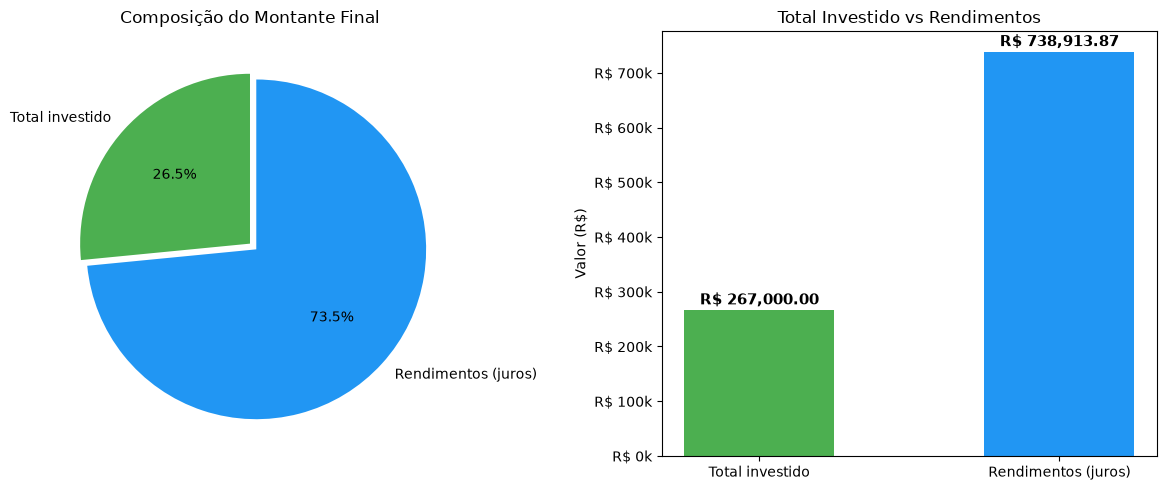

In [10]:
labels = ['Total investido', 'Rendimentos (juros)']
valores = [total_investido, saldo - total_investido]
cores = ['#4CAF50', '#2196F3']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pizza
ax1.pie(valores, labels=labels, autopct='%1.1f%%', startangle=90, colors=cores, explode=(0, 0.05))
ax1.set_title('Composição do Montante Final')

# Barra
barras = ax2.bar(labels, valores, color=cores, width=0.5)
for barra, valor in zip(barras, valores):
    ax2.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 10000,
             f'R$ {valor:,.2f}', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Valor (R$)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1000:,.0f}k'))
ax2.set_title('Total Investido vs Rendimentos')

plt.tight_layout()
plt.show()

## Planilha mês a mês

Abaixo, a simulação completa mês a mês com mês, ano, aporte, rendimento do mês, saldo acumulado e % da meta atingida.

In [11]:
import pandas as pd

# Recalcular mês a mês com detalhes
taxa_mensal = 0.0083
alvo = 1_000_000
saldo = 0
total_investido = 0
registros = []

for mes in range(1, meses_total + 1):
    if mes <= 24:
        aporte = 300
        fase = 1
    elif mes <= 48:
        aporte = 500
        fase = 2
    elif mes <= 72:
        aporte = 700
        fase = 3
    else:
        aporte = 1000
        fase = 4

    rendimento = saldo * taxa_mensal
    saldo = saldo * (1 + taxa_mensal) + aporte
    total_investido += aporte
    pct_meta = saldo / alvo * 100

    registros.append({
        'Mês': mes,
        'Ano': round(mes / 12, 1),
        'Fase': f'Fase {fase}',
        'Aporte (R$)': aporte,
        'Rendimento (R$)': round(rendimento, 2),
        'Saldo (R$)': round(saldo, 2),
        '% da Meta': round(pct_meta, 4),
    })

df = pd.DataFrame(registros)

# Mostrar tudo (pode ser grande, mas o Jupyter lida bem)
with pd.option_context('display.max_rows', None, 'display.float_format', '{:.2f}'.format):
    display(df)

print(f'\nTotal de linhas: {len(df)}')
print(f'Total investido: R$ {total_investido:,.2f}')
print(f'Saldo final: R$ {saldo:,.2f}')

,Mês,Ano,Fase,Aporte (R$),Rendimento (R$),Saldo (R$),% da Meta
0,1,0.10,Fase 1,300,0.00,300.00,0.03
1,2,0.20,Fase 1,300,2.49,602.49,0.06
2,3,0.20,Fase 1,300,5.00,907.49,0.09
3,4,0.30,Fase 1,300,7.53,1215.02,0.12
4,5,0.40,Fase 1,300,10.08,1525.11,0.15
5,6,0.50,Fase 1,300,12.66,1837.77,0.18
6,7,0.60,Fase 1,300,15.25,2153.02,0.22
7,8,0.70,Fase 1,300,17.87,2470.89,0.25
8,9,0.80,Fase 1,300,20.51,2791.40,0.28
9,10,0.80,Fase 1,300,23.17,3114.57,0.31



Total de linhas: 303
Total investido: R$ 267,000.00
Saldo final: R$ 1,005,913.87


### Exportar para CSV / Excel

Descomente a linha desejada para exportar a planilha:

In [12]:
# Exportar para CSV
# df.to_csv('simulacao_mes_a_mes.csv', index=False, decimal=',', sep=';')

# Exportar para Excel (precisa do openpyxl instalado: pip install openpyxl)
# df.to_excel('simulacao_mes_a_mes.xlsx', index=False)

print('Pronto! Descomente a linha desejada para exportar.')

Pronto! Descomente a linha desejada para exportar.
